<a href="https://colab.research.google.com/github/mariazafran/Herding--Breakdown-ML/blob/main/Herding_Breakdown_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# load your dataset
df = pd.read_csv('/content/drive/MyDrive/PhD_Research/Data/final_dataset.csv')

df.head()

Mounted at /content/drive


,CSAD,Rm,Rm_c,abs_Rm,Rm_sq,crisis,down,volatility,Rm_sq_crisis,Rm_sq_vol,Rm_sq_down
0,0.009319,0.012910,0.012540,0.012540,1.572582e-04,0,0,0.009035,0.0,1.420778e-06,0.000000
1,0.010087,0.001112,0.000742,0.000742,5.511968e-07,0,0,0.009243,0.0,5.094535e-09,0.000000
2,0.012903,0.009763,0.009393,0.009393,8.823599e-05,0,0,0.008745,0.0,7.715802e-07,0.000000
3,0.010790,0.003631,0.003262,0.003262,1.063862e-05,0,0,0.008712,0.0,9.268794e-08,0.000000
4,0.012294,-0.001568,-0.001938,0.001938,3.755427e-06,0,1,0.008337,0.0,3.130850e-08,0.000004


In [ ]:
# Create breakdown variable
df['breakdown'] = (df['CSAD'] > df['CSAD'].median()).astype(int)

# Check results
df[['CSAD','breakdown']].head()

,CSAD,breakdown
0,0.009319,0
1,0.010087,1
2,0.012903,1
3,0.010790,1
4,0.012294,1


In [ ]:
print(df['breakdown'].value_counts())

breakdown
0    310
1    309
Name: count, dtype: int64


This shows 50/50 means balanced data set. Ideal for ML. No biases

In [ ]:
#prediction stage as dataset is balaned and ideal
from sklearn.ensemble import RandomForestClassifier

# Define features (inputs)
features = ['abs_Rm','Rm_sq','volatility','down']
X = df[features]

# Target (output)
y = df['breakdown']

# Train model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

RandomForestClassifier(n_estimators=200, random_state=42)

Above output shows visual html display of trained ranfom forest model

RandomForestClassifier(n_estimators=200, random_state=42)

This Shows model built
Trees 200 and ready to use

Now we will check model accuracy expect from 0.7 to 0.9

In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X)
print("Accuracy:", accuracy_score(y, pred))

Accuracy: 1.0


Accuracy is 1 because model is trained and tested on same data thus it memorized the pattern instead of learning behaviour. This is referred as over-fitting.
We will fix this over-fitting through train / test split.

In [ ]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model again
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, pred_test))

Test Accuracy: 0.5


Initial accuracy = 1.0 → due to overfitting (model memorised data)
Then we run train–test split  which shown accuracy ≈ 0.5
Interpretation:
•Herding breakdown is not easily predictable using simple variables Indicating investors behaviour as nonlinear and complex.
•it also suggests that investor actions become uncertain and heterogeneous under volatility
This accuracy drop suggests that herding breakdown is dynamic and unpredictable, rather than a stable pattern.

Now we will move from classification toward probability and insigts. For this we will frst generste probability then plot it

In [ ]:
df['prob_breakdown'] = model.predict_proba(X)[:,1]

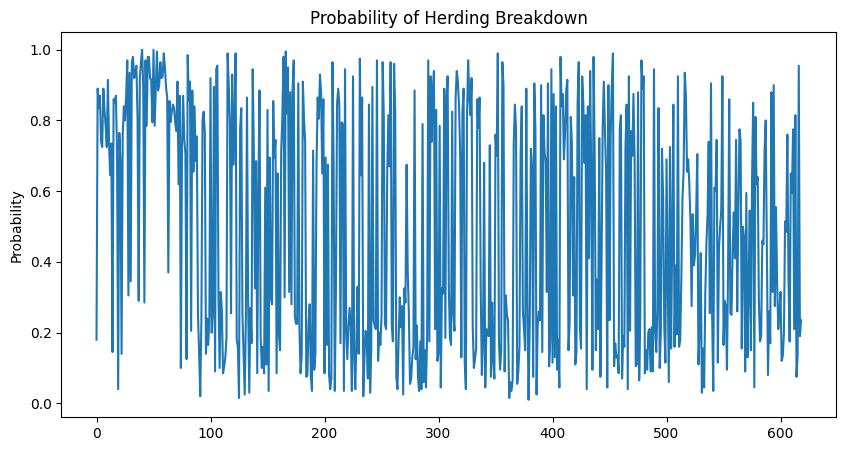

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['prob_breakdown'])
plt.title("Probability of Herding Breakdown")
plt.ylabel("Probability")
plt.show()

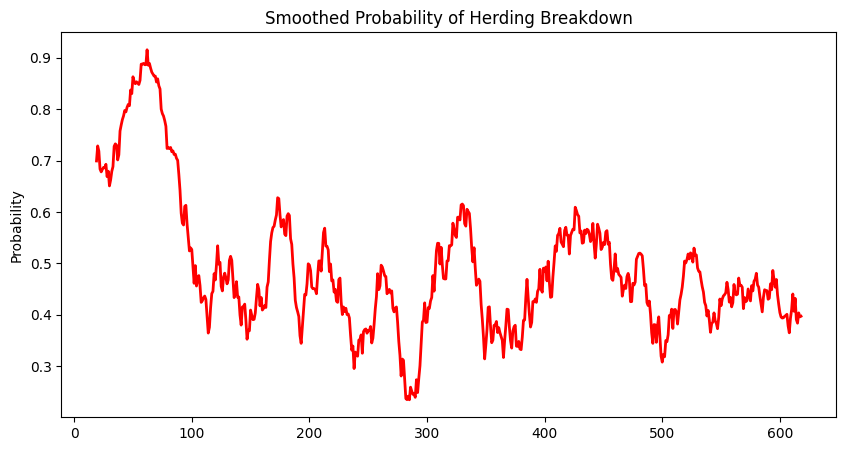

In [ ]:
# Smooth probability (rolling average)
df['prob_smooth'] = df['prob_breakdown'].rolling(20).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['prob_smooth'], color='red', linewidth=2)
plt.title("Smoothed Probability of Herding Breakdown")
plt.ylabel("Probability")
plt.show()

The smoothed probability of herding breakdown reveals a dynamic pattern over time, suggesting that collective market behaviour is unstable and subject to periodic disruption

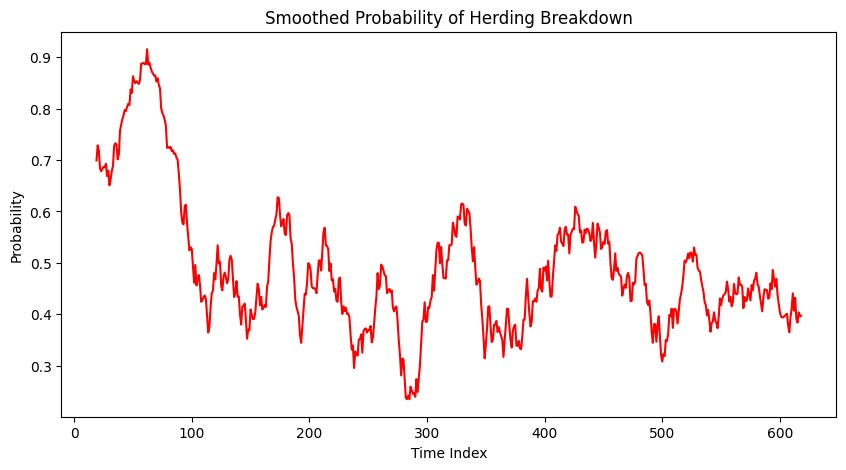

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['prob_smooth'], color='red')
plt.title("Smoothed Probability of Herding Breakdown")
plt.xlabel("Time Index")
plt.ylabel("Probability")
plt.show()

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PhD_Research/Data/final_dataset.csv', index_col=0)
df.index = pd.to_datetime(df.index)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['prob_smooth'], color='red')
plt.title("Smoothed Probability of Herding Breakdown Over Time")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.show()

KeyError: 'prob_smooth'

<Figure size 1000x500 with 0 Axes>

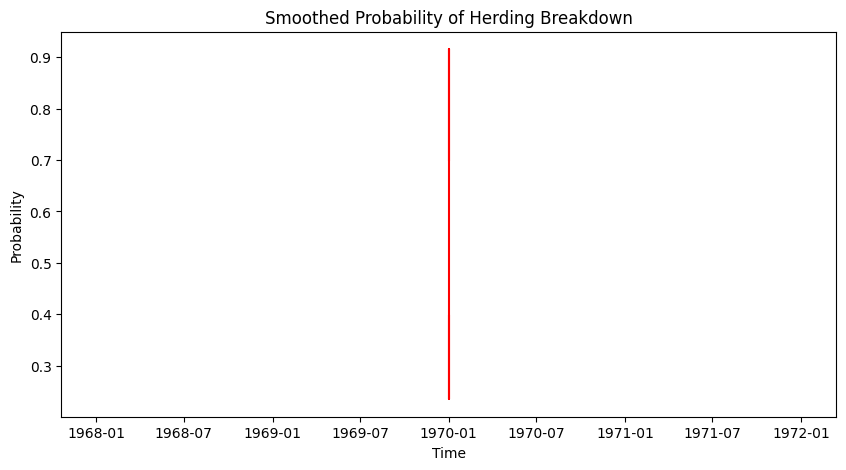

In [ ]:
# Step 1: Make sure probability exists
df['prob_breakdown'] = model.predict_proba(X)[:,1]

# Step 2: Create smooth version
df['prob_smooth'] = df['prob_breakdown'].rolling(20).mean()

# Step 3: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.index, df['prob_smooth'], color='red')
plt.title("Smoothed Probability of Herding Breakdown")
plt.xlabel("Time")
plt.ylabel("Probability")
plt.show()

In [ ]:
print(df['prob_breakdown'].describe())

count    619.000000
mean       0.491632
std        0.334320
min        0.010000
25%        0.170000
50%        0.445000
75%        0.830000
max        1.000000
Name: prob_breakdown, dtype: float64


These stats show of means stsndard deviation, min and maximum shows
1 probability is not constant and there is variation and model is okay

In [ ]:
# Step 1: Sort by index (VERY IMPORTANT)
df = df.sort_index()

# Step 2: Reset index (clean plotting)
df = df.reset_index(drop=True)

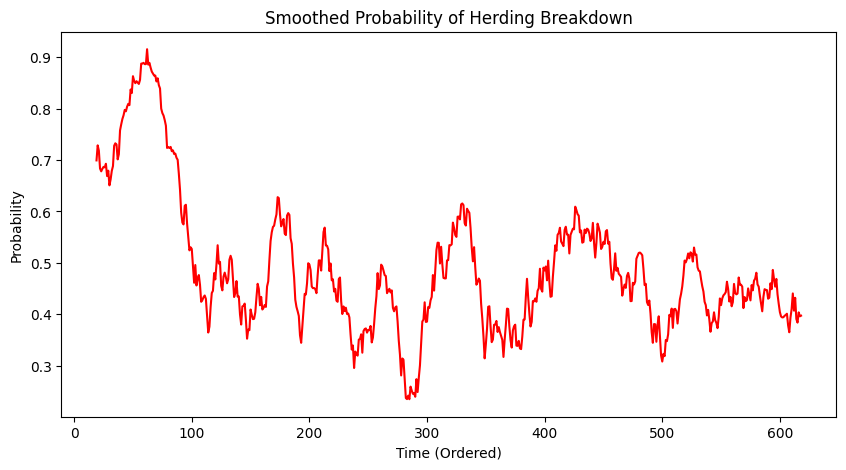

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['prob_smooth'], color='red')
plt.title("Smoothed Probability of Herding Breakdown")
plt.xlabel("Time (Ordered)")
plt.ylabel("Probability")
plt.show()

The graph is showing
Early period:
1: High probability (~0.7–0.9) indicates strong breakdown phases.
Middle:
2: Drops (~0.25–0.5) indicating more stable / less breakdown.
Later:
3: Fluctuating cycles (~0.3–0.6) indicates unstable but moderate behaviour.

This suggest herding behaviour is not constant, Moves in cycles and varry over time.

The smoothed probability of herding breakdown exhibits clear fluctuations over time, indicating that market behaviour is unstable and evolves dynamically rather than following a constant pattern

Now we will connect volatility with breakdown.if the trend is upward it proves higher volatility leads to increased breakdown.

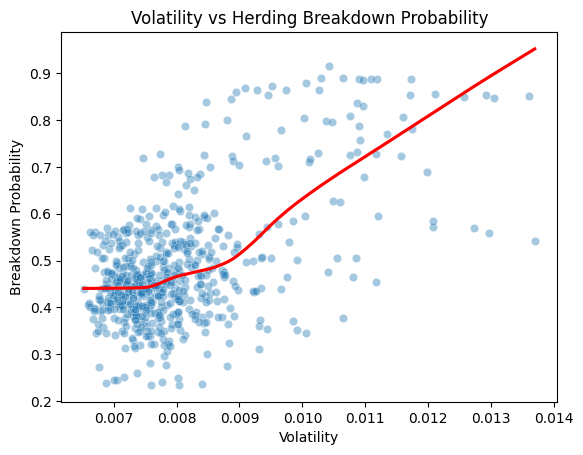

In [ ]:
import seaborn as sns

sns.scatterplot(x=df['volatility'], y=df['prob_smooth'], alpha=0.4)
sns.regplot(x=df['volatility'], y=df['prob_smooth'],
            scatter=False, lowess=True, color='red')

plt.title("Volatility vs Herding Breakdown Probability")
plt.xlabel("Volatility")
plt.ylabel("Breakdown Probability")
plt.show()

 Scattered observations shown  Non- Linear Trend

Interpretation:
When the volatility was low from 0.007  to 0.008 the breakdoen probability was in between 0.4 to 0.5.Furthermore, from 0.009 to 0.01 volatility the probability of breakdown increased from 0.5 to 0.7 and at highest volatility from 0.011 to 0.014 the probability of break down rose sharply from 0.8 to 0.95.

This proves Volatility significantly increases the probabilty of herding behaviour.As the increase in volatility increases the probability of breakdown significantly, indicating that higher uncertainty leads to greater divergence in investor behaviour